In [10]:
!pip install -U diffusers

## Local Inference on GPU
Model page: https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0

⚠️ If the generated code snippets do not work, please open an issue on either the [model repo](https://huggingface.co/stabilityai/stable-diffusion-xl-base-1.0)
			and/or on [huggingface.js](https://github.com/huggingface/huggingface.js/blob/main/packages/tasks/src/model-libraries-snippets.ts) 🙏

In [11]:
!pip install -U torch torchvision diffusers transformers accelerate

In [ ]:
import torch
from diffusers import DiffusionPipeline

# switch to "mps" for Apple devices; otherwise use CPU
device = "cpu"
pipe = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float32,
    device_map=device,
)

prompt = "Astronaut in a jungle, dancing , cold color palette, muted colors, detailed, 8k"
image = pipe(prompt).images[0]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

RuntimeError: mat1 and mat2 must have the same dtype, but got Half and Float

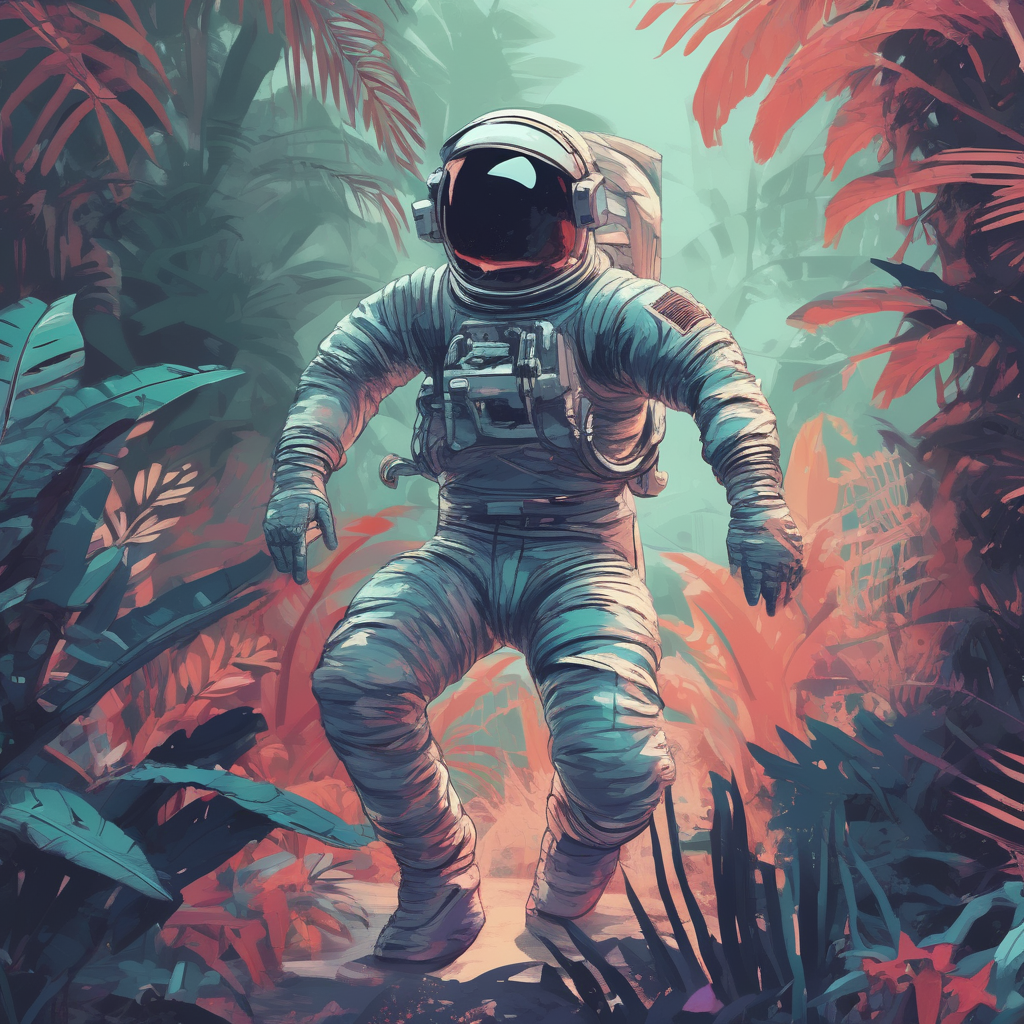

In [ ]:
image

## Remote Inference via Inference Providers
Ensure you have a valid **HF_TOKEN** set in your environment. You can get your token from [your settings page](https://huggingface.co/settings/tokens). Note: running this may incur charges above the free tier.
The following Python example shows how to run the model remotely on HF Inference Providers, automatically selecting an available inference provider for you.
For more information on how to use the Inference Providers, please refer to our [documentation and guides](https://huggingface.co/docs/inference-providers/en/index).

In [ ]:
import os
os.environ['HF_TOKEN'] = 'YOUR_TOKEN_HERE'

In [ ]:
import os
from huggingface_hub import InferenceClient

client = InferenceClient(
    provider="auto",
    api_key=os.environ["HF_TOKEN"],
)

# output is a PIL.Image object
image = client.text_to_image(
    "Astronaut riding a horse",
    model="stabilityai/stable-diffusion-xl-base-1.0",
)

HfHubHTTPError: Client error '401 Unauthorized' for url 'https://fal.run/fal-ai/fast-sdxl'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401